### RaschPy matrix MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the matrix parameterisation, each rater has a full, independent severity for every item x threshold combination — the most flexible (and most heavily parameterised) of the five rater representations.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Matrix(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:391: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_32779/2151788252.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Matrix(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_matrix_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_matrix_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     4.0     5.0     3.0     4.0     4.0     3.0     2.0   
        Person_2     0.0     1.0     3.0     0.0     3.0     0.0     0.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     3.0     4.0      0.0      2.0      1.0  
        Person_2     0.0     2.0      3.0      0.0      2.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the matrix parameterisation (a full, independent severity per rater x item x threshold combination). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_matrix()

CPU times: user 7.07 ms, sys: 261 μs, total: 7.33 ms
Wall time: 7.2 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -1.042453
Item_2   -0.507735
dtype: float64

Since this is simulated data, we know the true generating item locations (mfrm.generating.items) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE. Recovery for the rater severities will be noisier than the other parameterisations (see below), since the matrix model spreads the same amount of data across many more free parameters (a severity for every rater x item x threshold cell):

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:               {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


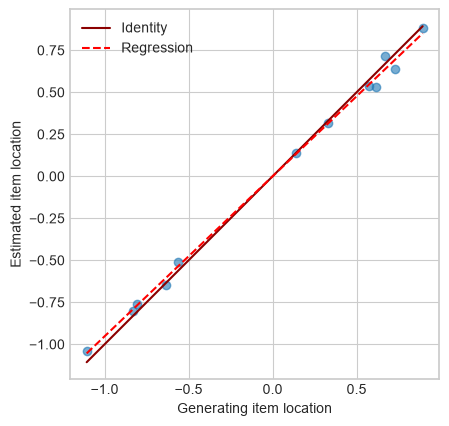

item location Pearson correlation:               0.998
item location SD ratio (estimated / generating): 0.954
item location regression coefficient:            0.952
item location RMSE:                              0.05


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_matrix_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_matrix(full=True)
mfrm.item_stats_matrix.to_csv('mfrm_matrix_item_stats.csv')

CPU times: user 22.2 s, sys: 123 ms, total: 22.3 s
Wall time: 22.3 s


Check the item statistics table

In [14]:
mfrm.item_stats_matrix

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,-1.042,0.042,-1.129,-0.962,1600,0.690,0.995,-0.122,1.022,0.629,0.708,0.705
Item_2,-0.508,0.036,-0.576,-0.436,1600,0.607,0.988,-0.326,1.038,1.061,0.732,0.726
Item_3,-0.759,0.036,-0.835,-0.694,1600,0.653,0.995,-0.137,1.005,0.163,0.716,0.720
Item_4,0.537,0.041,0.461,0.623,1600,0.412,0.910,-2.611,0.885,-3.380,0.775,0.760
Item_5,-0.803,0.038,-0.878,-0.728,1600,0.653,0.966,-0.964,0.955,-1.286,0.717,0.710
Item_6,0.136,0.034,0.069,0.197,1600,0.488,0.996,-0.109,1.011,0.327,0.764,0.760
Item_7,0.531,0.041,0.457,0.613,1600,0.407,0.961,-1.092,0.982,-0.507,0.763,0.755
Item_8,0.315,0.037,0.249,0.391,1600,0.455,0.925,-2.175,0.929,-2.033,0.782,0.761
Item_9,-0.645,0.039,-0.729,-0.573,1600,0.625,0.907,-2.706,0.920,-2.314,0.753,0.730
Item_10,0.882,0.039,0.808,0.962,1600,0.350,0.976,-0.677,0.989,-0.310,0.758,0.750


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_matrix(full=True)
mfrm.threshold_stats_matrix.to_csv('mfrm_matrix_threshold_stats.csv')

CPU times: user 80 ms, sys: 1.66 ms, total: 81.7 ms
Wall time: 81.5 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_matrix

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-1.161,0.042,-1.237,-1.077,1.000,-0.021,0.997,-0.151,1.005,0.426,0.405
Threshold 2,-0.913,0.032,-0.975,-0.847,0.989,-0.934,0.997,-0.145,1.027,0.418,0.393
Threshold 3,-0.745,0.026,-0.792,-0.693,0.992,-0.800,0.987,-0.760,1.022,0.531,0.506
Threshold 4,1.093,0.032,1.024,1.142,0.992,-0.820,1.001,0.081,1.014,0.594,0.581
Threshold 5,1.726,0.038,1.640,1.789,0.970,-2.540,0.963,-1.973,1.078,0.617,0.585


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

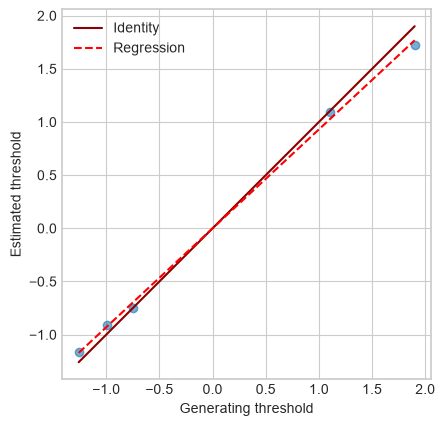

threshold Pearson correlation:               0.999
threshold SD ratio (estimated / generating): 0.931
threshold regression coefficient:            0.93
threshold RMSE:                              0.097


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_matrix_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file. By default (`marginal=True`) this reports one row per rater, with item and threshold marginal severities. Pass `marginal=False` for the full (item, threshold) cell-level table instead.

In [18]:
%%time
mfrm.rater_stats_df_matrix()
mfrm.rater_stats_matrix.to_csv('mfrm_matrix_rater_stats.csv')

CPU times: user 41.9 ms, sys: 1.45 ms, total: 43.3 ms
Wall time: 43.1 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_matrix

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.114  0.167   -0.177  0.128    0.208  0.148   -0.293  0.129   
Rater_2   -0.352  0.196   -0.235  0.133    0.099  0.180    0.102  0.120   
Rater_3    0.245  0.139   -0.006  0.112   -0.144  0.161    0.256  0.116   
Rater_4    0.341  0.153    0.017  0.139    0.120  0.119   -0.093  0.126   
Rater_5    0.068  0.171    0.167  0.118   -0.192  0.159    0.012  0.137   
Rater_6   -0.320  0.174    0.637  0.138   -0.258  0.145    0.079  0.154   
Rater_7   -0.105  0.212   -0.205  0.156   -0.056  0.143    0.130  0.124   
Rater_8    0.009  0.181   -0.199  0.120    0.223  0.144   -0.194  0.116   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1    0.122  0.139  ...       0.111       0.013  0.075      -0.048   
Rater_2   -0.034  0.140  ...       0.120       0.062  0.073       0.122   
Rater_3   -0.292  0.142  ...       0.111      -0.043  0.078      -0.044   
Rater_4   -0.318  0.241  ...       0.136      -0.311  0.083       0.125   
Rater_5   -0.218  0.146  ...       0.097      -0.096  0.080      -0.137   
Rater_6    0.293  0.130  ...       0.105       0.375  0.066      -0.156   
Rater_7    0.525  0.135  ...       0.109       0.066  0.077      -0.010   
Rater_8   -0.078  0.126  ...       0.111      -0.066  0.083       0.147   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.087      -0.141  0.110             2400.0    0.953     0.946  
Rater_2  0.077      -0.040  0.130             2400.0    0.942     0.971  
Rater_3  0.074       0.179  0.115             2400.0    0.993     0.989  
Rater_4  0.077      -0.029  0.113             2400.0    1.010     1.010  
Rater_5  0.074       0.201  0.122             2400.0    0.930     0.955  
Rater_6  0.084      -0.065  0.135             2400.0    0.934     0.949  
Rater_7  0.074       0.228  0.113             2400.0    0.984     1.010  
Rater_8  0.086      -0.333  0.131             2400.0    0.928     0.932  

[8 rows x 37 columns]

And the same recovery check for the full rater x item x threshold severities, against `mfrm.generating.facet_effects`. Since these are per rater x item x threshold, we flatten with `.stack()` first — expect this to be the noisiest of the recovery plots, for the reason noted above:

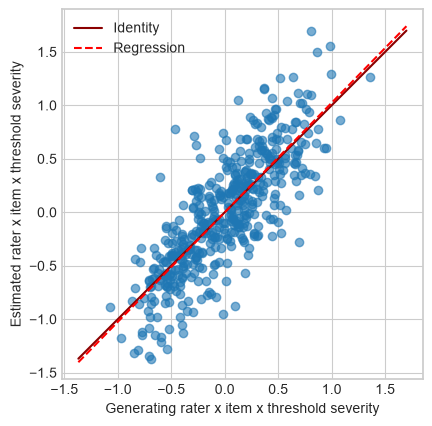

rater x item x threshold severity Pearson correlation:               0.802
rater x item x threshold severity SD ratio (estimated / generating): 1.278
rater x item x threshold severity regression coefficient:            1.024
rater x item x threshold severity RMSE:                              0.329


In [20]:
orig_severities = mfrm.generating.facet_effects.stack()
est_severities = mfrm.raters_matrix.stack()
recovery_plot(orig_severities, est_severities, 'rater x item x threshold severity', 'my_mfrm_matrix_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_matrix(full=True)
mfrm.person_stats_matrix.to_csv('mfrm_matrix_person_stats.csv')

CPU times: user 14.2 ms, sys: 736 μs, total: 15 ms
Wall time: 14.9 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_matrix.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.428,0.104,0.091,294,480,0.612,0.768,0.737,-1.676,-1.911
Person_2,-1.509,0.110,0.107,103,480,0.215,0.946,0.931,-0.322,-0.337
Person_3,1.312,0.121,0.121,365,480,0.760,1.012,1.003,0.126,0.067
Person_4,1.341,0.121,0.112,367,480,0.765,0.852,0.915,-0.963,-0.533
Person_5,-2.538,0.156,0.153,39,480,0.081,0.954,0.957,-0.148,-0.024
Person_6,-1.583,0.112,0.111,97,480,0.202,0.977,0.975,-0.108,-0.078
Person_7,0.187,0.101,0.105,271,480,0.565,1.076,1.096,0.574,0.691
Person_8,-0.290,0.098,0.089,222,480,0.462,0.836,0.900,-1.265,-0.686
Person_9,-0.022,0.099,0.092,250,480,0.521,0.871,0.874,-0.942,-0.877
Person_10,-0.989,0.101,0.102,150,480,0.312,1.019,1.003,0.179,0.071


And the same recovery check for person locations, against `mfrm.generating.persons`:

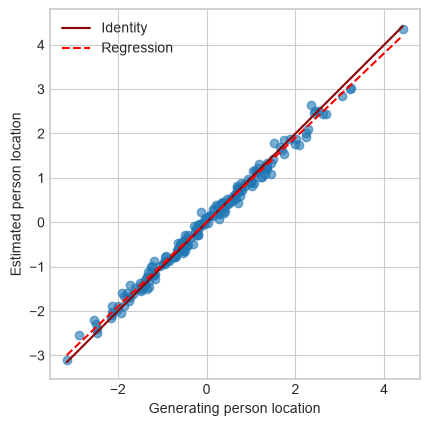

person location Pearson correlation:               0.996
person location SD ratio (estimated / generating): 0.955
person location regression coefficient:            0.951
person location RMSE:                              0.134


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_matrix, 'person location', 'my_mfrm_matrix_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_matrix()
mfrm.test_stats_matrix.to_csv('mfrm_matrix_test_stats.csv')

CPU times: user 2.62 ms, sys: 485 μs, total: 3.11 ms
Wall time: 3.09 ms


Check the test statistics table

In [25]:
mfrm.test_stats_matrix

,Items,Persons
Mean,0.000,0.006
SD,0.699,1.264
Separation ratio,18.135,11.067
Strata,24.514,15.090
Reliability,0.997,0.992


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_matrix()
mfrm.item_residual_correlations_matrix.to_csv('mfrm_matrix_item_residual_correlations.csv')
mfrm.item_loadings_matrix.to_csv('mfrm_matrix_item_loadings.csv')

CPU times: user 5.82 ms, sys: 1.64 ms, total: 7.46 ms
Wall time: 8.37 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
round(mfrm.item_residual_correlations_matrix, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.054,0.001,0.031,0.014,0.005,-0.022,-0.021,-0.019,0.025,0.003,-0.012
Item_2,-0.054,1.000,-0.018,-0.048,-0.059,-0.001,0.023,0.007,0.042,-0.046,-0.018,-0.041
Item_3,0.001,-0.018,1.000,0.007,0.001,0.004,-0.011,0.004,-0.011,-0.019,-0.035,-0.005
Item_4,0.031,-0.048,0.007,1.000,0.007,-0.052,0.050,-0.013,0.006,0.006,0.017,-0.025
Item_5,0.014,-0.059,0.001,0.007,1.000,-0.015,0.024,-0.008,-0.015,-0.007,-0.018,-0.034
Item_6,0.005,-0.001,0.004,-0.052,-0.015,1.000,-0.037,-0.015,-0.033,-0.036,0.016,-0.025
Item_7,-0.022,0.023,-0.011,0.050,0.024,-0.037,1.000,-0.006,-0.007,0.016,-0.024,-0.052
Item_8,-0.021,0.007,0.004,-0.013,-0.008,-0.015,-0.006,1.000,-0.026,-0.028,0.000,0.011
Item_9,-0.019,0.042,-0.011,0.006,-0.015,-0.033,-0.007,-0.026,1.000,0.004,-0.005,-0.011
Item_10,0.025,-0.046,-0.019,0.006,-0.007,-0.036,0.016,-0.028,0.004,1.000,-0.039,-0.002


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_matrix['PC 1'], 3)

Item_1    -0.118
Item_2     0.193
Item_3    -0.001
Item_4    -0.135
Item_5    -0.111
Item_6     0.096
Item_7    -0.053
Item_8     0.073
Item_9     0.062
Item_10   -0.115
Item_11    0.040
Item_12    0.027
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_matrix()
mfrm.rater_residual_correlations_matrix.to_csv('mfrm_matrix_rater_residual_correlations.csv')
mfrm.rater_loadings_matrix.to_csv('mfrm_matrix_rater_loadings.csv')

CPU times: user 9.55 ms, sys: 570 μs, total: 10.1 ms
Wall time: 10.1 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
round(mfrm.rater_residual_correlations_matrix, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,-0.019,-0.001,-0.017,-0.031,0.008,0.016,0.020
Rater_2,-0.019,1.000,0.016,-0.037,-0.024,-0.031,-0.000,0.009
Rater_3,-0.001,0.016,1.000,-0.079,0.003,-0.011,0.001,-0.055
Rater_4,-0.017,-0.037,-0.079,1.000,-0.008,0.018,-0.018,-0.020
Rater_5,-0.031,-0.024,0.003,-0.008,1.000,-0.033,-0.012,-0.048
Rater_6,0.008,-0.031,-0.011,0.018,-0.033,1.000,-0.029,-0.039
Rater_7,0.016,-0.000,0.001,-0.018,-0.012,-0.029,1.000,0.025
Rater_8,0.020,0.009,-0.055,-0.020,-0.048,-0.039,0.025,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_matrix['PC 1'], 3)

Rater_1    0.083
Rater_2   -0.179
Rater_3   -0.205
Rater_4    0.248
Rater_5   -0.070
Rater_6    0.148
Rater_7   -0.059
Rater_8    0.016
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

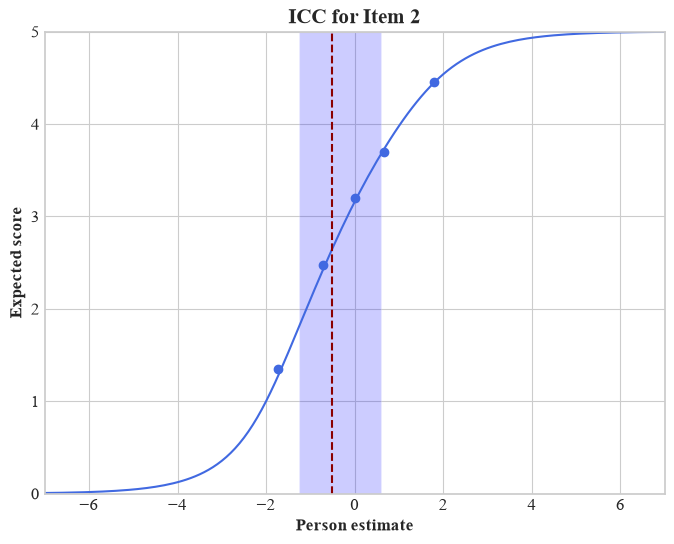

In [32]:
mfrm.icc_matrix('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_matrix_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

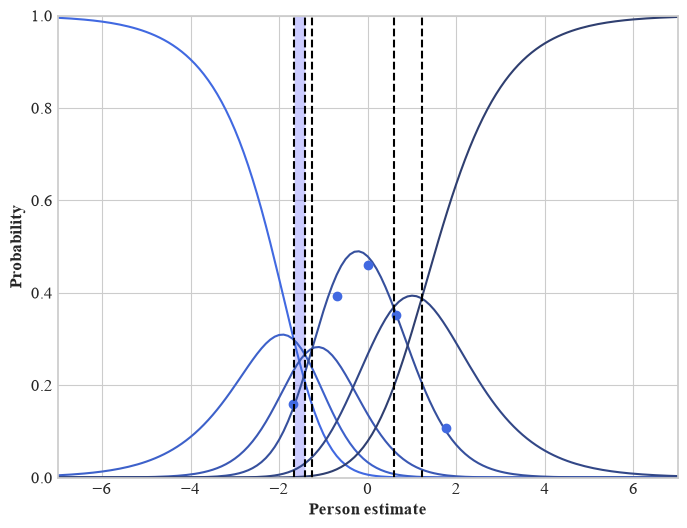

In [33]:
mfrm.crcs_matrix('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_matrix_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

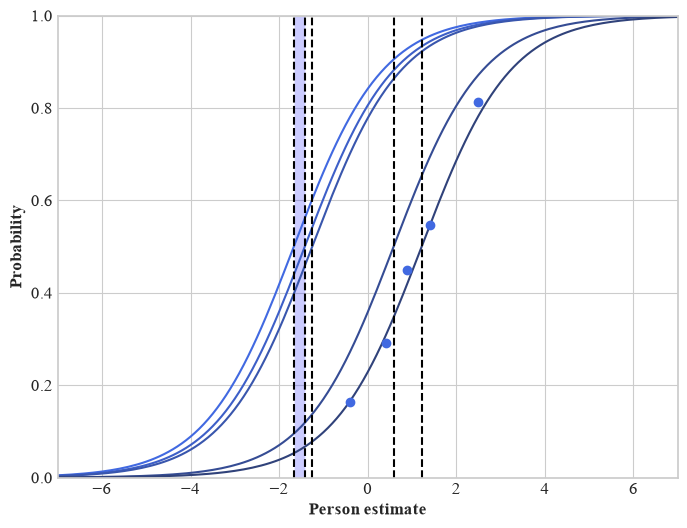

In [34]:
mfrm.threshold_ccs_matrix('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_matrix_threshold_ccs')

Produce an item information function curve for Item 2

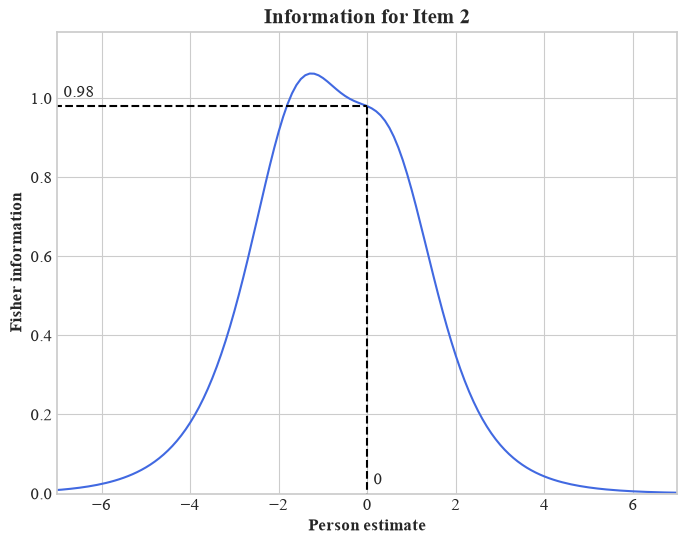

In [35]:
mfrm.iic_matrix('Item_2', title='Information for Item 2', point_info_lines=[0], point_info_labels=True,
                xmin=-7, xmax=7, filename='my_mfrm_matrix_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

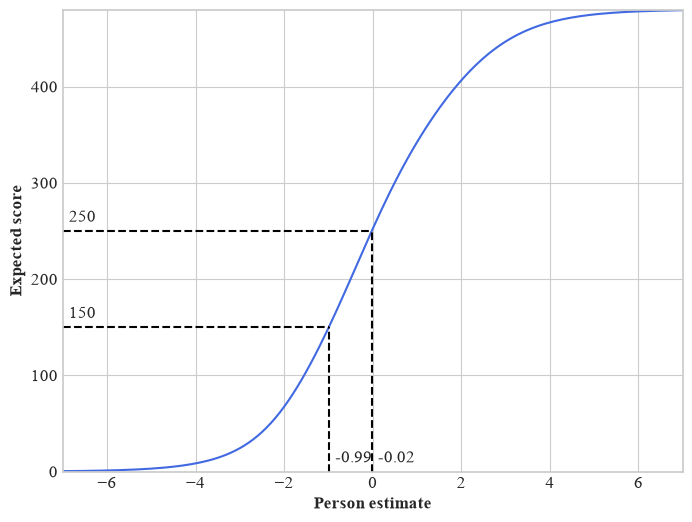

In [36]:
mfrm.tcc_matrix(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_matrix_tcc')

Produce a test information curve

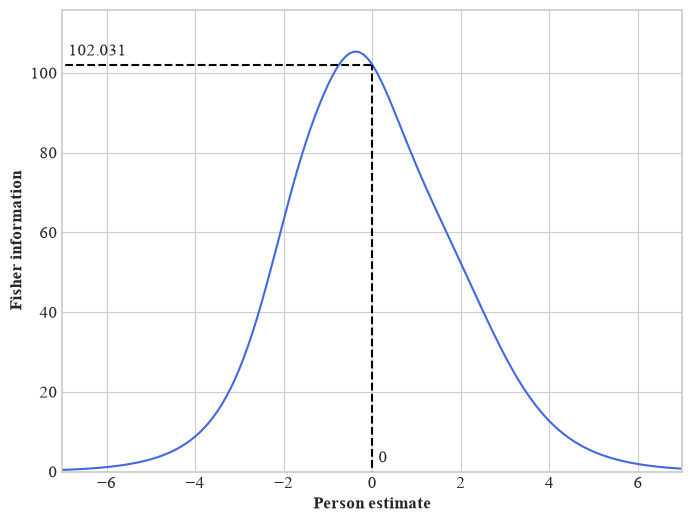

In [37]:
mfrm.test_info_matrix(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_matrix_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

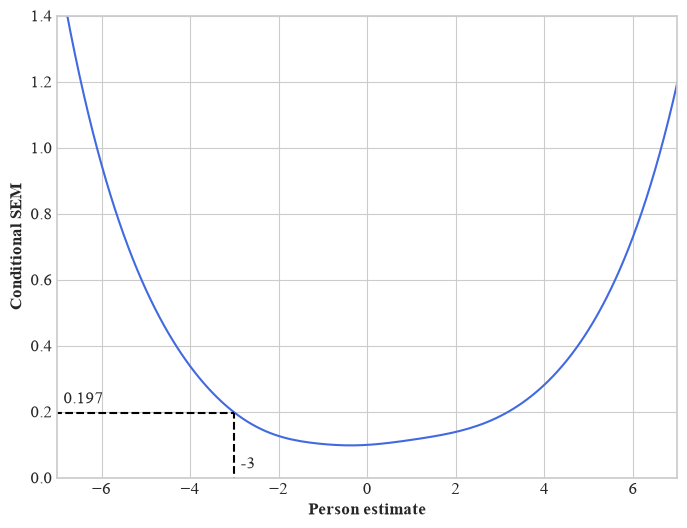

In [38]:
mfrm.test_csem_matrix(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_matrix_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

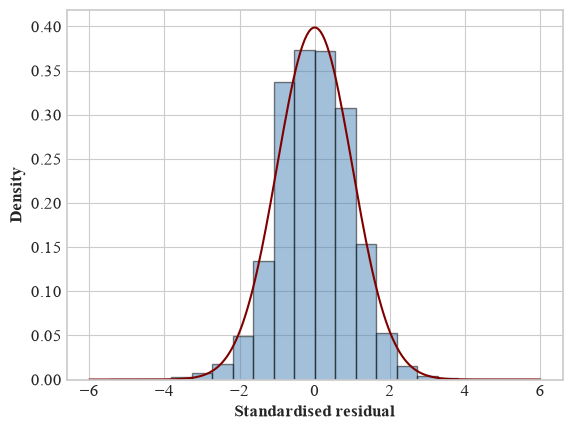

In [39]:
mfrm.std_residuals_plot_matrix(bin_width=0.6, normal=True, filename='my_mfrm_matrix_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_matrix_anchor(anchors)

CPU times: user 1.33 ms, sys: 240 μs, total: 1.57 ms
Wall time: 1.42 ms


Check the anchored item locations against the unanchored ones.

In [41]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_matrix})
round(item_check, 3)

,Unanchored,Anchored
Item_1,-1.042,-0.917
Item_2,-0.508,-0.570
Item_3,-0.759,-0.650
Item_4,0.537,0.568
Item_5,-0.803,-0.896
Item_6,0.136,0.194
Item_7,0.531,0.497
Item_8,0.315,0.392
Item_9,-0.645,-0.656
Item_10,0.882,0.872


Check the anchored thresholds against the unanchored thresholds

In [42]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                                'Anchored': mfrm.anchor_thresholds_matrix})
round(threshold_check, 3)

,Unanchored,Anchored
1,-1.161,-1.285
2,-0.913,-0.865
3,-0.745,-0.777
4,1.093,1.170
5,1.726,1.757


Check the anchored marginal item severities against the unanchored ones - two dataframes

In [43]:
round(mfrm.marginal_raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.114,-0.177,0.208,-0.293,0.122,-0.169,0.128,-0.306,-0.150,-0.601,-0.054,-0.174
Rater_2,-0.352,-0.235,0.099,0.102,-0.034,-0.081,-0.430,0.230,-0.058,0.120,-0.002,-0.327
Rater_3,0.245,-0.006,-0.144,0.256,-0.292,0.165,-0.311,0.180,0.316,0.432,-0.348,-0.070
Rater_4,0.341,0.017,0.120,-0.093,-0.318,0.164,0.321,0.050,-0.307,-0.145,-0.135,0.049
Rater_5,0.068,0.167,-0.192,0.012,-0.218,-0.050,0.080,0.186,0.176,-0.162,0.042,0.073
Rater_6,-0.320,0.637,-0.258,0.079,0.293,-0.021,-0.277,-0.111,-0.036,-0.035,0.294,0.007
Rater_7,-0.105,-0.205,-0.056,0.130,0.525,0.080,0.331,-0.073,0.184,0.150,-0.110,0.370
Rater_8,0.009,-0.199,0.223,-0.194,-0.078,-0.089,0.158,-0.156,-0.124,0.240,0.313,0.071


In [44]:
round(mfrm.anchor_marginal_raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.027,-0.077,0.138,-0.286,0.252,-0.189,0.201,-0.345,-0.100,-0.553,0.081,-0.044
Rater_2,-0.439,-0.135,0.028,0.109,0.097,-0.101,-0.357,0.191,-0.008,0.169,0.133,-0.196
Rater_3,0.158,0.094,-0.215,0.263,-0.161,0.145,-0.238,0.142,0.366,0.480,-0.213,0.060
Rater_4,0.254,0.117,0.049,-0.086,-0.188,0.144,0.394,0.012,-0.257,-0.096,-0.001,0.180
Rater_5,-0.019,0.267,-0.263,0.019,-0.088,-0.070,0.153,0.147,0.226,-0.113,0.177,0.203
Rater_6,-0.407,0.738,-0.328,0.086,0.423,-0.041,-0.204,-0.149,0.014,0.013,0.429,0.138
Rater_7,-0.192,-0.105,-0.126,0.137,0.656,0.061,0.404,-0.112,0.234,0.199,0.024,0.500
Rater_8,-0.078,-0.099,0.153,-0.188,0.052,-0.109,0.231,-0.195,-0.075,0.289,0.448,0.202


Check the anchored marginal threshold severities against the unanchored ones - two dataframes

In [45]:
round(mfrm.marginal_raters_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.038,-0.348,0.013,-0.048,-0.141
Rater_2,-0.460,-0.088,0.062,0.122,-0.040
Rater_3,-0.121,0.205,-0.043,-0.044,0.179
Rater_4,-0.030,0.271,-0.311,0.125,-0.029
Rater_5,-0.029,0.137,-0.096,-0.137,0.201
Rater_6,0.106,-0.155,0.375,-0.156,-0.065
Rater_7,0.243,-0.018,0.066,-0.010,0.228
Rater_8,0.329,-0.005,-0.066,0.147,-0.333


In [46]:
round(mfrm.anchor_marginal_raters_thresholds, 3)

,1,2,3,4,5
Rater_1,0.198,-0.283,0.157,-0.012,-0.059
Rater_2,-0.255,-0.055,0.174,0.126,0.010
Rater_3,-0.032,0.121,-0.047,-0.156,0.114
Rater_4,0.089,0.217,-0.284,0.043,-0.064
Rater_5,0.080,0.073,-0.080,-0.229,0.155
Rater_6,0.209,-0.224,0.385,-0.254,-0.117
Rater_7,0.265,-0.168,-0.004,-0.189,0.096
Rater_8,0.438,-0.068,-0.049,0.056,-0.378
